In [1]:
# Stock Price Movement Prediction (Jupyter-ready Python script)
# Project: Predicting Next-Day Stock Direction (Up=1 / Down=0)
import os
from datetime import datetime, timedelta

import numpy as np
import pandas as pdz    

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report,
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

# For fetching data
try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except Exception:
    YFINANCE_AVAILABLE = False




plt.style.use("seaborn-v0_8-darkgrid")
sns.set_theme()





In [3]:
# --------------------------
# Cell 2: User params & Data Fetch
# --------------------------
# Choose a ticker from NSE (if using Yahoo Finance, append .NS)
# Examples: "TCS.NS", "RELIANCE.NS", "INFY.NS", "HDFCBANK.NS"
TICKER = "RELIANCE.NS"  # select stock
YEARS = 2  # number of years to fetch
END_DATE = datetime.today().date()
START_DATE = END_DATE - timedelta(days=int(YEARS * 365.25))

print(f"Fetching {TICKER} from {START_DATE} to {END_DATE}")

if not YFINANCE_AVAILABLE:
    raise ImportError(
        "yfinance is not installed. Install with: pip install yfinance"
    )

raw = yf.download(TICKER, start=START_DATE.isoformat(), end=(END_DATE + timedelta(days=1)).isoformat(), progress=False)

if raw.empty:
    raise RuntimeError("No data fetched. Check ticker or your internet connection.")

# Keep only OHLCV and ensure chronological order
data = raw[['Open','High','Low','Close','Volume']].copy()
data.index = pd.to_datetime(data.index)
data.sort_index(inplace=True)
data.reset_index(inplace=True)   # adding date as column
data.rename(columns={"index": "Date"}, inplace=True)

Fetching RELIANCE.NS from 2023-11-07 to 2025-11-06


C:\Users\adith\AppData\Local\Temp\ipykernel_13320\968713352.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(TICKER, start=START_DATE.isoformat(), end=(END_DATE + timedelta(days=1)).isoformat(), progress=False)


In [5]:
data

Price,Open,High,Low,Close,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-11-06,1157.582230,1161.403919,1154.256867,1160.907593,10647304
2023-11-07,1158.450749,1160.957222,1151.254016,1153.363403,6960204
2023-11-08,1157.433272,1161.900210,1152.345926,1159.368896,7884494
2023-11-09,1159.344193,1159.368912,1143.635388,1146.787109,14513610
2023-11-10,1144.305465,1149.665815,1140.583017,1148.946045,7734954
...,...,...,...,...,...
2025-10-29,1490.000000,1508.300049,1488.099976,1504.199951,11884745
2025-10-30,1500.000000,1503.099976,1484.000000,1488.500000,9318663


In [16]:
# --------------------------
#  Data cleaning
# --------------------------
print("Missing values before:", data.isna().sum().to_dict())

# Fill missing values forward/backward
data.ffill(inplace=True)
data.bfill(inplace=True)
print("Missing values after:", data.isna().sum().to_dict())

# Detect extreme outliers using rolling z-score
z_window = 20
roll_mean = data["Close"].rolling(z_window, min_periods=1).mean()
roll_std = data["Close"].rolling(z_window, min_periods=1).std().replace(0, np.nan).bfill()
z_score = (data["Close"] - roll_mean) / roll_std

outliers = (z_score.abs() > 6).sum()
print(f"Large z-score outliers in Close (>6σ): {outliers}")


Missing values before: {('Open', 'RELIANCE.NS'): 0, ('High', 'RELIANCE.NS'): 0, ('Low', 'RELIANCE.NS'): 0, ('Close', 'RELIANCE.NS'): 0, ('Volume', 'RELIANCE.NS'): 0}
Missing values after: {('Open', 'RELIANCE.NS'): 0, ('High', 'RELIANCE.NS'): 0, ('Low', 'RELIANCE.NS'): 0, ('Close', 'RELIANCE.NS'): 0, ('Volume', 'RELIANCE.NS'): 0}
Large z-score outliers in Close (>6σ): Ticker
RELIANCE.NS    0
dtype: int64


In [4]:
# --------------------------
# Cell 4: Feature engineering
# --------------------------

def SMA(series, window):
    return series.rolling(window).mean()

def EMA(series, window):
    return series.ewm(span=window, adjust=False).mean()

def RSI(series, period=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -1 * delta.clip(upper=0)
    ma_up = up.ewm(alpha=1/period, adjust=False).mean()
    ma_down = down.ewm(alpha=1/period, adjust=False).mean()
    rs = ma_up / (ma_down + 1e-9)
    return 100 - (100 / (1 + rs))

def MACD(series, fast=12, slow=26, signal=9):
    ema_fast = EMA(series, fast)
    ema_slow = EMA(series, slow)
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    hist = macd_line - signal_line
    return macd_line, signal_line, hist

def bollinger_bands(series, window=20, num_sd=2):
    ma = series.rolling(window).mean()
    sd = series.rolling(window).std()
    upper = ma + (sd * num_sd)
    lower = ma - (sd * num_sd)
    return upper, lower

# Work on a copy
df = data.copy()

# Compute indicators
df["SMA_10"] = SMA(df["Close"], 10)
df["SMA_20"] = SMA(df["Close"], 20)
df["RSI_14"] = RSI(df["Close"], 14)
df["MACD_line"], df["MACD_signal"], df["MACD_hist"] = MACD(df["Close"])
df["BB_upper"], df["BB_lower"] = bollinger_bands(df["Close"], 20, 2)
df["BB_width"] = (df["BB_upper"] - df["BB_lower"]) / df["SMA_20"]

# Lagged returns and volatility
for lag in [1, 2, 3, 5]:
    df[f"Return_lag_{lag}"] = df["Close"].pct_change(lag)

df["Return"] = df["Close"].pct_change(1)
df["Vol_10"] = df["Return"].rolling(10).std()
df["Vol_ratio_5"] = df["Volume"] / df["Volume"].rolling(5).mean()

# Drop initial NaNs due to indicators
df.dropna(inplace=True)


In [1]:



# --------------------------
# Cell 5: Target variable
# --------------------------

# Fix MultiIndex column issue if it exists (safeguard)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Predict next day's direction: 1 = Up, 0 = Down
df["Close_next"] = df["Close"].shift(-1)
df["Target"] = (df["Close_next"] > df["Close"]).astype(int)

# Drop last row since it has no next day
df.dropna(subset=["Target"], inplace=True)

print(df[[ "Close", "Close_next", "Target"]].head())



NameError: name 'df' is not defined

In [6]:
# --------------------------
# Cell 6: Train/Test split (time-based)
# --------------------------
# Use the first 80% of time for training, last 20% for testing (chronological)
split_frac = 0.8
split_index = int(len(df) * split_frac)
train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print(f"Total rows: {len(df)}, Train: {len(train)}, Test: {len(test)}")

Total rows: 474, Train: 379, Test: 95


In [7]:
# --------------------------
# Cell 7: Preparing data for modeling
# --------------------------
feature_cols = [
    'SMA_10',' ','RSI_14','MACD_line','MACD_signal','MACD_hist',
    'BB_upper','BB_lower','BB_width','Vol_10','Vol_ratio_5',
    'Return_lag_1','Return_lag_2','Return_lag_3','Return_lag_5'
]

# Some features (SMA/BB) relate to price scale — we will use returns / differences where sensible
# Create normalized / derived features to remove scale dependency
train_X = train[feature_cols].copy()
test_X = test[feature_cols].copy()
train_y = train['Target'].values
test_y = test['Target'].values

# Fill any remaining NaNs (should be none)
train_X.ffill(inplace=True)
train_X.bfill(inplace=True)
test_X.ffill(inplace=True)
test_X.bfill(inplace=True)

# Standardize features
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

In [8]:
# --------------------------
# Cell 8: Model training
# --------------------------
results = {}

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(train_X_scaled, train_y)
results['LogisticRegression'] = lr

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(train_X, train_y)  # tree-based models don't need scaled features
results['RandomForest'] = rf

# XGBoost (optional)
if XGBOOST_AVAILABLE:
    xgb = XGBClassifier( eval_metric='logloss', random_state=42)
    xgb.fit(train_X, train_y)
    results['XGBoost'] = xgb
else:
    print("XGBoost not available — skipping XGBoost model. Install xgboost to enable it.")

In [9]:
# --------------------------
# Cell 9: Evaluation helper & predictions
# --------------------------

def eval_model(model, X, y_true, scaler_for_model=None, use_scaled=False, name=None):
    if use_scaled:
        X_input = scaler_for_model.transform(X) if scaler_for_model is not None else X
    else:
        X_input = X
    y_pred = model.predict(X_input)
    y_proba = None
    try:
        # some models have predict_proba
        y_proba = model.predict_proba(X_input)[:,1]
    except Exception:
        pass
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))
    return {'y_pred': y_pred, 'y_proba': y_proba, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm}

# Evaluate on test set
model_metrics = {}

# Logistic uses scaled features
model_metrics['LogisticRegression'] = eval_model(lr, test_X, test_y, scaler_for_model=scaler, use_scaled=True, name='LogisticRegression')

# Random Forest uses unscaled features
model_metrics['RandomForest'] = eval_model(rf, test_X, test_y, scaler_for_model=None, use_scaled=False, name='RandomForest')

if XGBOOST_AVAILABLE:
    model_metrics['XGBoost'] = eval_model(xgb, test_X, test_y, use_scaled=False, name='XGBoost')



--- LogisticRegression ---
Accuracy: 0.4842, Precision: 0.4444, Recall: 0.2609, F1: 0.3288
Confusion Matrix:
 [[34 15]
 [34 12]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.69      0.58        49
           1       0.44      0.26      0.33        46

    accuracy                           0.48        95
   macro avg       0.47      0.48      0.45        95
weighted avg       0.47      0.48      0.46        95

--- RandomForest ---
Accuracy: 0.5579, Precision: 0.5345, Recall: 0.6739, F1: 0.5962
Confusion Matrix:
 [[22 27]
 [15 31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.45      0.51        49
           1       0.53      0.67      0.60        46

    accuracy                           0.56        95
   macro avg       0.56      0.56      0.55        95
weighted avg       0.57      0.56      0.55        95

--- XGBoost ---
Accuracy: 0.6000, Precision: 0

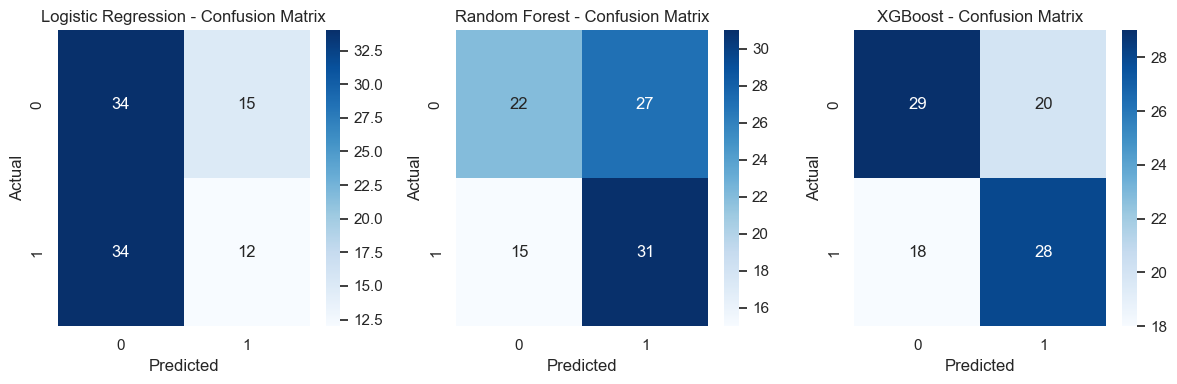

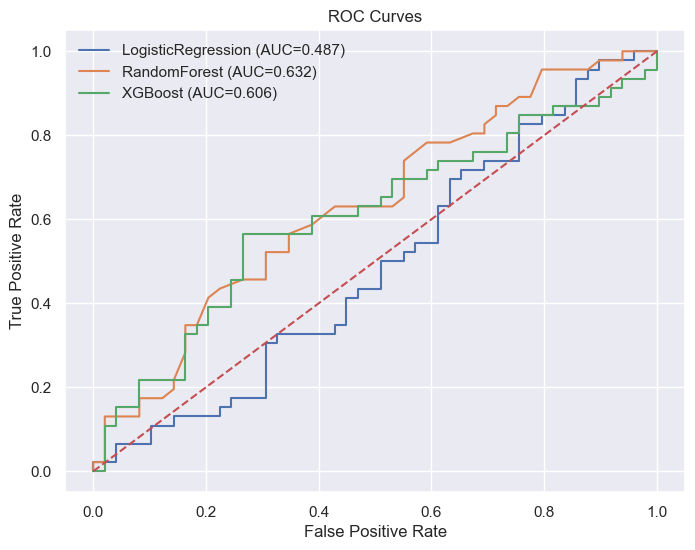

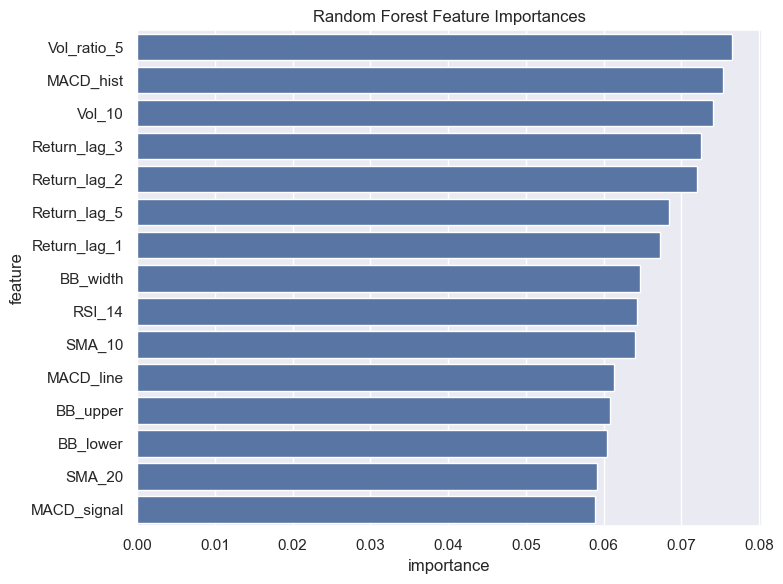

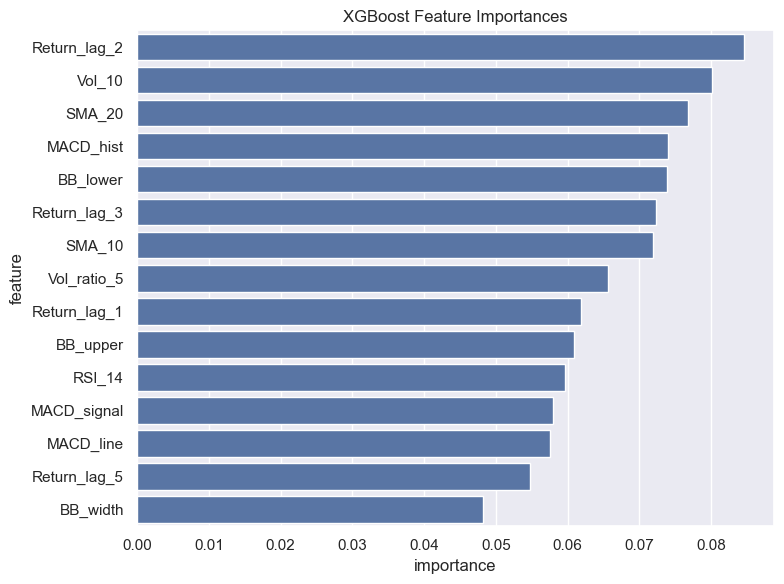

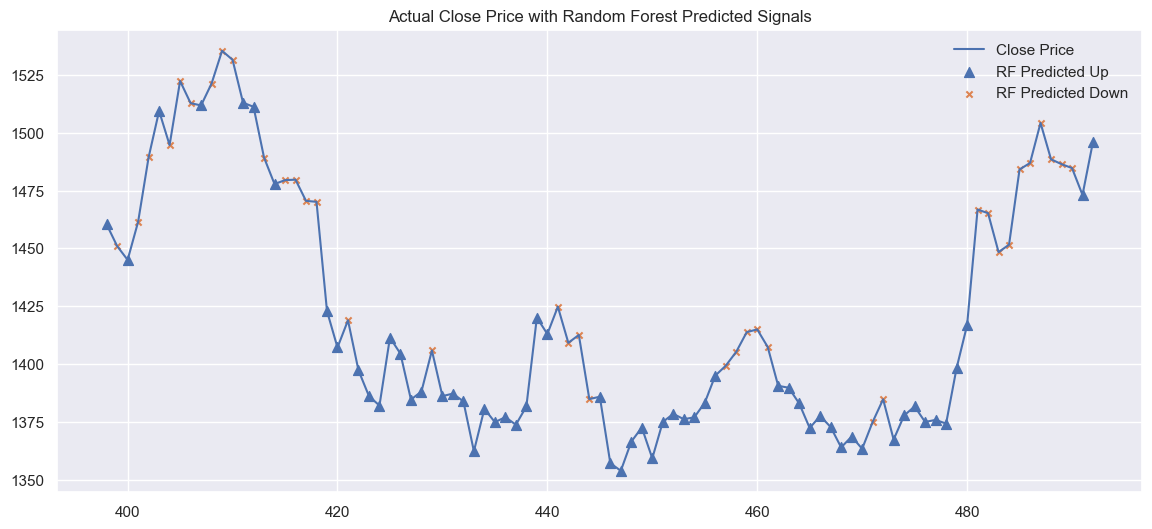

In [10]:
# --------------------------
# Cell 10: Visualizations
# --------------------------
# Confusion matrix heatmaps
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
cm = model_metrics['LogisticRegression']['cm']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,3,2)
cm = model_metrics['RandomForest']['cm']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

if XGBOOST_AVAILABLE:
    plt.subplot(1,3,3)
    cm = model_metrics['XGBoost']['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('XGBoost - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC curves (where probabilities available)
plt.figure(figsize=(8,6))
for name, m in results.items():
    info = model_metrics.get(name)
    if info and info['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(test_y, info['y_proba'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

# Feature importance for tree-based models
if 'RandomForest' in results:
    importances = results['RandomForest'].feature_importances_
    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': importances}).sort_values('importance', ascending=False)
    plt.figure(figsize=(8,6))
    sns.barplot(data=fi_df, x='importance', y='feature')
    plt.title('Random Forest Feature Importances')
    plt.tight_layout()
    plt.show()

if XGBOOST_AVAILABLE and 'XGBoost' in results:
    importances = results['XGBoost'].feature_importances_
    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': importances}).sort_values('importance', ascending=False)
    plt.figure(figsize=(8,6))
    sns.barplot(data=fi_df, x='importance', y='feature')
    plt.title('XGBoost Feature Importances')
    plt.tight_layout()
    plt.show()

# Actual vs Predicted signal plot (on test set)
plt.figure(figsize=(14,6))
plt.plot(test.index, test['Close'], label='Close Price')
# overlay predicted up days as markers
pred_lr = model_metrics['LogisticRegression']['y_pred']
pred_rf = model_metrics['RandomForest']['y_pred']

# We'll plot predicted up-days for RF as green triangles and down as red x (example)
up_idx = test.index[pred_rf==1]
down_idx = test.index[pred_rf==0]
plt.scatter(up_idx, test.loc[up_idx,'Close'], marker='^', s=50, label='RF Predicted Up')
plt.scatter(down_idx, test.loc[down_idx,'Close'], marker='x', s=20, label='RF Predicted Down')
plt.title('Actual Close Price with Random Forest Predicted Signals')
plt.legend()
plt.show()


In [11]:
# --------------------------
# Cell 11: Insights & Reporting
# --------------------------
# Print top features from Random Forest
if 'RandomForest' in results:
    print('\nTop features (Random Forest):')
    print(fi_df.head(10).to_string(index=False))

# Summary of metrics
print('\nModel performance summary:')
for name, info in model_metrics.items():
    print(f"{name}: Accuracy={info['acc']:.4f}, Precision={info['prec']:.4f}, Recall={info['rec']:.4f}, F1={info['f1']:.4f}")




Top features (Random Forest):
     feature  importance
Return_lag_2    0.084535
      Vol_10    0.080053
      SMA_20    0.076798
   MACD_hist    0.074053
    BB_lower    0.073801
Return_lag_3    0.072274
      SMA_10    0.071925
 Vol_ratio_5    0.065646
Return_lag_1    0.061869
    BB_upper    0.060907

Model performance summary:
LogisticRegression: Accuracy=0.4842, Precision=0.4444, Recall=0.2609, F1=0.3288
RandomForest: Accuracy=0.5579, Precision=0.5345, Recall=0.6739, F1=0.5962
XGBoost: Accuracy=0.6000, Precision=0.5833, Recall=0.6087, F1=0.5957


In [12]:
# --------------------------
# Cell 12: Save models and artifacts (optional)
# --------------------------
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(lr, 'models/logistic_model.joblib')
joblib.dump(rf, 'models/random_forest_model.joblib')
if XGBOOST_AVAILABLE:
    joblib.dump(xgb, 'models/xgboost_model.joblib')
joblib.dump(scaler, 'models/scaler.joblib')

print('Models saved to ./models')

# End of script

Models saved to ./models
